In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [3]:
x = data[['AveRooms']].values
y = data['Price'].values

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [6]:
w = 0
b =0
learning_rate = 0.01
epochs = 1000
cost_history = []
n = len(x_train_scaled)
for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    if i % 100 == 0:
        cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
        print(f"Epoch {i}, Cost = {cost:.4f}")
        cost_history.append(cost)
y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [7]:
print("Gradient Descent")
print("----------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [8]:
x_train_ne = np.c_[np.ones((len(x_train),1)), x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)), x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train

y_pred_ne = x_test_ne @ theta

In [9]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:", theta[0])
print("Slope:", theta[1])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [10]:
sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

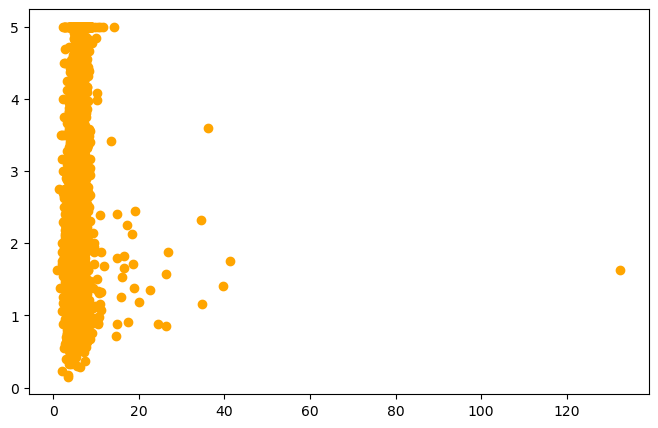

In [11]:
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, color='orange', label='Actual Data')

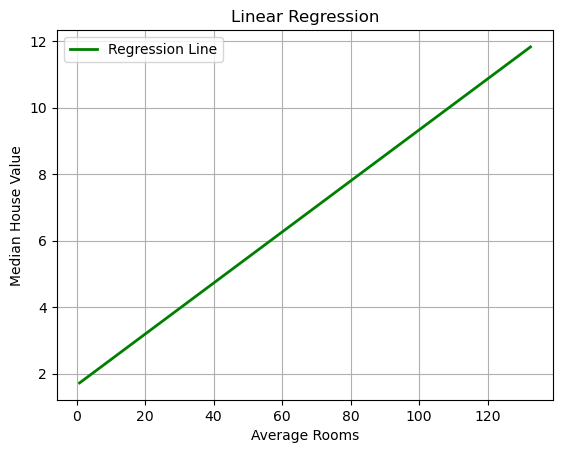

In [12]:
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='green',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

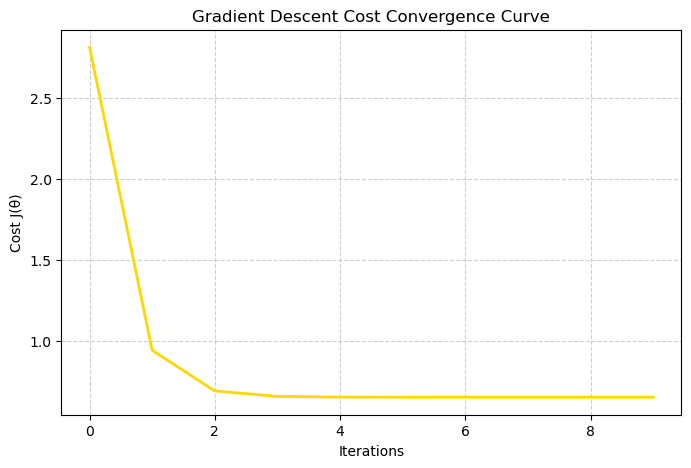

In [13]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color='gold', linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(θ)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()